In [65]:
###########  PRICE ------- PARKING -------------->

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [68]:
df = pd.read_csv('MagicBricks.csv')

In [69]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [70]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [72]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [74]:
df.shape

(1259, 11)

In [75]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64

In [76]:
## remove missing value

df = df.dropna(subset=['Parking','Price'])

In [77]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         0
Furnishing       1
Locality         0
Parking          0
Price            0
Status           0
Transaction      0
Type             1
Per_Sqft       221
dtype: int64

In [78]:
# remove duplicates

df = df.drop_duplicates()

df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [79]:
### remove invalid Parking

df = df[df['Parking']>0]

In [80]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [82]:
### remove outliers 

Q1 = df[['Parking', 'Price']].quantile(0.25)
Q3 = df[['Parking', 'Price']].quantile(0.75)
IQR = Q3 - Q1

df = df[
    ~(((df[['Parking', 'Price']] < (Q1 - 1.5 * IQR)) |
       (df[['Parking', 'Price']] > (Q3 + 1.5 * IQR))).any(axis=1))
]

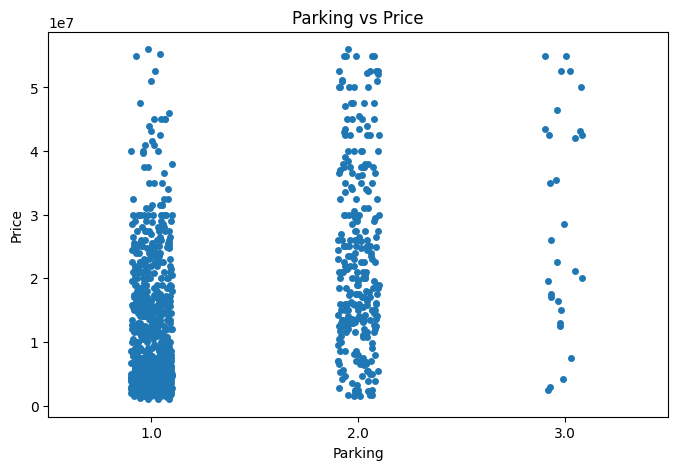

In [84]:
# =====================================
# EXPLORATORY DATA ANALYSIS
# =====================================

plt.figure(figsize=(8,5))

sns.stripplot(
    x='Parking',
    y='Price',
    data=df,
    jitter=True
)

plt.title('Parking vs Price')
plt.show()

In [86]:

# Correlation
correlation = df[['Parking', 'Price']].corr()
print(correlation)

          Parking     Price
Parking  1.000000  0.411888
Price    0.411888  1.000000


In [88]:
# =====================================
# FEATURE SELECTION
# =====================================

X = df[['Parking']]
y = df['Price']

In [89]:
# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
# =====================================
# MODEL TRAINING
# =====================================

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [91]:
# =====================================
# PREDICTION
# =====================================

y_pred = model.predict(X_test)

In [92]:
y_pred

array([12163407.33873589, 12163407.33873589, 23024942.75104028,
       12163407.33873589, 12163407.33873589, 12163407.33873589,
       12163407.33873589, 23024942.75104028, 12163407.33873589,
       23024942.75104028, 12163407.33873589, 12163407.33873589,
       12163407.33873589, 12163407.33873589, 12163407.33873589,
       33886478.16334468, 12163407.33873589, 12163407.33873589,
       12163407.33873589, 23024942.75104028, 23024942.75104028,
       23024942.75104028, 12163407.33873589, 12163407.33873589,
       12163407.33873589, 23024942.75104028, 12163407.33873589,
       12163407.33873589, 12163407.33873589, 12163407.33873589,
       23024942.75104028, 23024942.75104028, 12163407.33873589,
       12163407.33873589, 23024942.75104028, 12163407.33873589,
       12163407.33873589, 12163407.33873589, 12163407.33873589,
       12163407.33873589, 12163407.33873589, 23024942.75104028,
       12163407.33873589, 23024942.75104028, 12163407.33873589,
       12163407.33873589, 12163407.33873

In [94]:

# CUSTOM PREDICTION


sample = pd.DataFrame({'Parking':[2]})
predicted_price = model.predict(sample)

print(f"Predicted Price for 2 Bathrooms: {predicted_price[0]:.2f}")

Predicted Price for 2 Bathrooms: 23024942.75


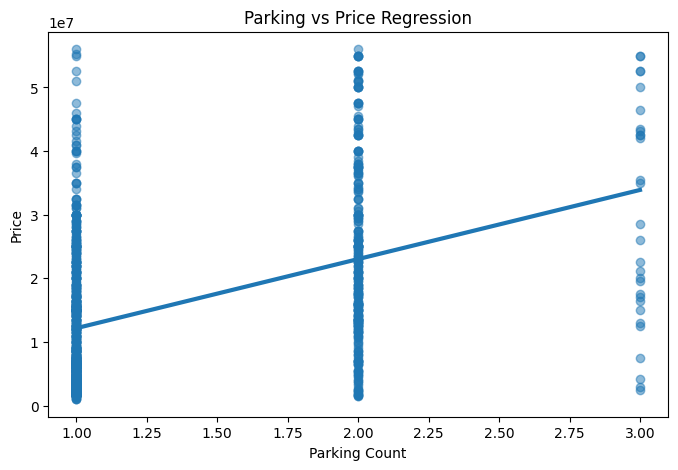

In [96]:
# REGRESSION LINE
# =====================================

sorted_df = df.sort_values(by='Parking')

plt.figure(figsize=(8,5))

plt.scatter(df['Parking'], df['Price'], alpha=0.5)

plt.plot(
    sorted_df['Parking'],
    model.predict(sorted_df[['Parking']]),
    linewidth=3
)

plt.xlabel('Parking Count')
plt.ylabel('Price')
plt.title('Parking vs Price Regression')

plt.show()

In [97]:
# MODEL EVALUATION
# =====================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 9224591.74
MSE  : 134100843834832.91
RMSE : 11580191.87
R2   : 0.0541


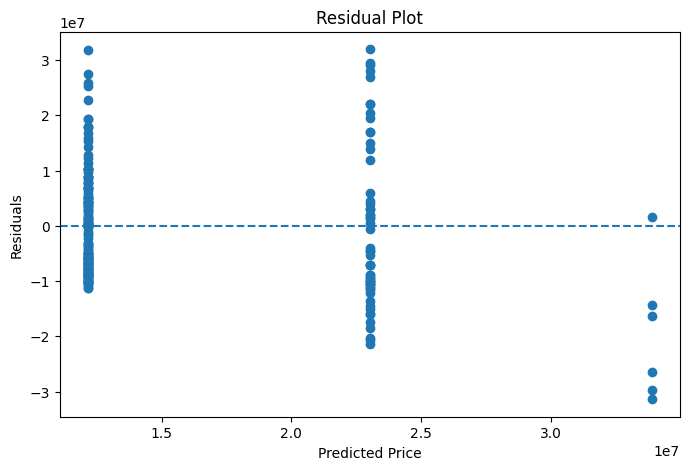

In [98]:
# RESIDUAL ANALYSIS
# =====================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [ ]:
#####Final Analysis
###Strengths
"""Correct use of regression pipeline
Good beginner-level ML implementation
Proper train-test split concept
Correct use of sklearn regression"""
###Main Weaknesses
"""Bathroom alone is weak predictor
Missing preprocessing
Missing outlier handling
Weak visualization choice
Missing residual analysis
Limited interpretation of metrics"""

Important ML Understanding

Even if notebook works technically, prediction quality may still be weak because:

real estate prices depend on many features together
single-feature regression oversimplifies the problem
Better Future Direction